# Kerr oscilator model

This model describes a single photonic mode subject to photon-photon interaction U, two-photon drive F , and losses $\gamma$. We work here in the frequency frame of the drive,
such that $\Delta = \omega_0 − \omega_d$ , where $\omega_0$ is the mode bare frequency and $\omega_d$ is the drive frequency. It is well known to display bistability , i.e., the coexistence of two stablesteady-state solutions at mean-field level, which seemed tocontradict the necessary uniqueness of the quantum ground state. [1]


When two photon driving is used, the system has a parity symmetry; it has been shown theoretically that this symmetry can be spontaneously broken in the steady state, leading to a continuous phase transition. Recently, this symmetry breaking has found applications in quantum error correction . Furthermore, phase transitions in either a few or a lattice of coupled Kerr oscillators have also been explored. Dissipative phase transitions have also been studied in a dissipative cavity with other types of nonlinearity, such as coupling with atoms. [2]

Previous approaches to the phase transition in a Kerr oscillator are usually limited to finite system size. Here, using the Keldysh formalism, we access the thermodynamic limit directly. [2]

[1] : Analytical phase boundary of a quantum driven-dissipative Kerr oscillator from classical stochastic instantons https://journals.aps.org/prresearch/pdf/10.1103/528d-l76d 

[2] : Driven-dissipative phase transition in a Kerr oscillator: From semiclassical PT symmetry to quantum fluctuations doi: 
10.1103/PhysRevA.103.033711

$$
\hat H  = -\Delta \hat a^\dagger \hat a + K\hat a^{\dagger2} \hat a^2 -  \epsilon(\hat a^{\dagger2} + \hat a^2)
$$

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


# Parametros]
N = 50              # dim Hilbert space
# Loss 
g1 = 0.01         
g2 = 0.1 
g3 = 0.05
g4 = 0.1


K = 1           # Interaction, Kerr NL
Delta = 1.5*K      # Detuning
        
eps = 1            # Squeezing

# Operadores
a = destroy(N)  
H = - Delta*a.dag()*a + K*a.dag()*a.dag()*a*a + eps*(a.dag()*a.dag() + a*a) # 2 foton pump 
# Aqui en los operadores de salto tomo en cuenta los 2 canales de 1 fotón y 2 fotones.
S = [np.sqrt(g1)*a,
     np.sqrt(g2)*a.dag(), 
     np.sqrt(g3)*a*a,
     np.sqrt(g4)*a.dag()*a.dag()
    ]

# Liouvillian

L = liouvillian(H, S)
eigs = L.eigenenergies()


## Ecuacion de Lindblad

$$
\frac{d\hat\rho}{dt} = -i[\hat H ,\hat \rho] + \gamma_1 \mathbb{D}[\hat a^\dagger] + \gamma_1 \mathbb{D}[\hat a] + \gamma_1 \mathbb{D}[\hat a^{2\dagger}] + \gamma_1 \mathbb{D}[\hat a^2]
$$
Donde $\mathbb D[\hat L]$ es el disipador con operador de salto L.
$$
\mathbb D[\hat L] = \hat L^\dagger \hat \rho \hat L - \frac{1}{2} \{\hat L^\dagger \hat L, \hat \rho\}
$$

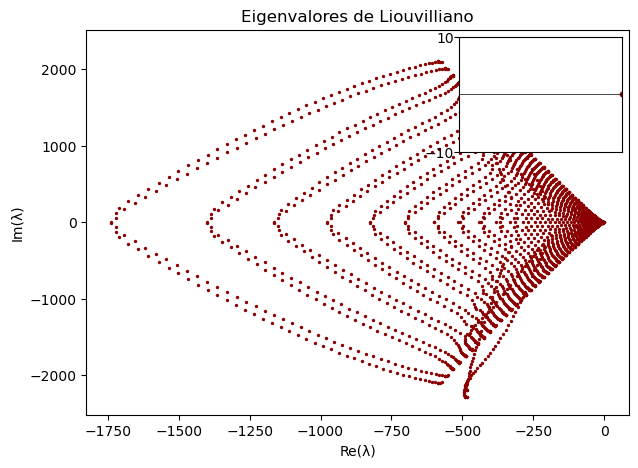

In [14]:
X = np.real(eigs)
Y = np.imag(eigs)

fig, ax = plt.subplots(figsize=(7,5))

# Grafica principal
ax.scatter(X, Y, s=2, c='darkred')
ax.set_xlabel("Re(λ)")
ax.set_ylabel("Im(λ)")
ax.set_title("Eigenvalores de Liouvilliano")
# -------------------------
# Zoom
# -------------------------
axins = inset_axes(ax, width="30%", height="30%", loc='upper right')

axins.scatter(X, Y, s=10, c='darkred')

# Limites de la region a ampliar
x1, x2 = -0.5, 0
y1, y2 = -10, 10

axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.axhline(0, c='black', lw=0.5)

# Opcional: quitar labels pequeños
axins.tick_params(axis='y',
                  direction='out',
                  labelsize=10,
                  pad=0)
axins.set_xticks([])
axins.set_yticks([y1,y2])

plt.savefig('eigsKerr.png')
plt.show()
